## PydanticAI 이미지 이해

- [PydanticAI 이미지/오디오/비디오/문서 입력 공식 문서](https://ai.pydantic.dev/input/#image-input)
- [Gemini API 이미지 이해 문서](https://ai.google.dev/gemini-api/docs/vision)

**실습 목표**
- PydanticAI의 `BinaryContent`, `ImageUrl`을 사용하여 이미지를 Agent에 전달하는 방법을 익힙니다.
- 단일/다중 이미지 분석, 객체 감지(구조화된 출력)를 실습합니다.

### Gemini 이미지 이해 기초

#### 지원 모델
| 모델 시리즈 | 버전 | 특징 |
|------------|------|------|
| **Gemini 2.5** | Flash, Flash-Lite, Pro | 최신 기능, segment 지원 |
| **Gemini 2.0** | Flash, Flash-Lite | 객체 감지 강화 |

**처리 한도** : 요청당 최대 **3,600개** 이미지


#### 지원 이미지 형식
| 형식 | MIME 타입 | 특징 |
|:----:|:---------:|:-----|
| PNG | `image/png` | 무손실, 투명도  |
| JPEG | `image/jpeg` | 범용, 압축 |
| WEBP | `image/webp` | Google 개발, 효율적 |
| HEIC/HEIF | `image/heic`, `image/heif` | Apple 기본 형식 |

#### 고급 기능
| 기능 | 지원 모델 | 주요 특징 |
|------|----------|:-----------|
| **객체 감지** | Gemini 2.0+ | • 경계 상자 [ymin, xmin, ymax, xmax]<br>• 0-1000 정규화 좌표<br>• 맞춤 라벨 지원 |
| **세그멘테이션** | Gemini 2.5+ | • JSON 출력 (bbox + mask)<br>• Base64 PNG 마스크<br>|

- 객체 감지/세그멘테이션 같은 시각적 작업에서는 추론 과정이 오히려 정확도를 떨어뜨릴 수 있어서, `thinking_budget=0`으로 설정하여 추론을 비활성화하면 더 나은 결과를 얻을 수 있다고 공식 문서에서 권장하고 있습니다
- thinking_budget은 Gemini 모델이 답변하기 전에 **내부적으로 생각하는 시간(토큰 수)** 을 제어하는 파라미터입니다.

#### 팁 및 권장사항
- 이미지가 올바르게 회전되었는지 확인합니다.
- 흐릿하지 않고 선명한 이미지를 사용하세요.
- 텍스트가 포함된 단일 이미지를 사용하는 경우 contents 배열의 이미지 부분 뒤에 텍스트 프롬프트를 배치합니다.

- 객체 탐지 및 세그멘테이션 예시

![image.png](https://ai.google.dev/static/gemini-api/docs/images/segmentation.jpg?hl=ko)

### 환경 설정

실습에 필요한 패키지를 설치하고, API 키를 설정합니다.

In [ ]:
# 필요한 패키지를 한 번에 설치합니다
# !pip install -q pydantic-ai-slim[google] python-dotenv pydantic Pillow matplotlib

# uv 권장! uv 환경에서는 위 pip 대신 터미널에서 uv sync 명령어로 설치하세요:
# uv sync

**실습**
- 환경변수를 로드하고 API 키가 올바르게 설정되었는지 확인합니다.
- `.env` 파일에 `GEMINI_API_KEY`를 설정한 후 아래 셀을 실행합니다.

### 3시 3분에 시작하겠습니다~!

In [1]:
# ========================================
# 필요한 라이브러리를 불러옵니다
# ========================================

import os
import time
import json
from pprint import pprint
from pathlib import Path
from typing import List

from dotenv import load_dotenv
from PIL import Image
from pydantic import BaseModel, Field
from pydantic_ai import Agent, BinaryContent
from pydantic_ai.models.google import GoogleModelSettings

# .env 파일에서 API 키 로드
load_dotenv()
api_key = os.getenv('GEMINI_API_KEY')
gemini_model = os.getenv('GEMINI_MODEL', 'gemini-3.1-flash-lite-preview')

# PydanticAI는 GEMINI_API_KEY 환경변수를 자동으로 인식합니다
# 모델 ID 형식: 'google-gla:{모델명}'
model_id = f'google-gla:{gemini_model}'

# API 키 유효성 검사
api_key_valid = api_key and 'YOUR_API_KEY' not in api_key
print(f"API 키 설정 확인: {'✓' if api_key_valid else '✗'}")
if not api_key_valid:
    print("⚠️  .env 파일에서 GEMINI_API_KEY를 실제 API 키로 설정해주세요!")
print(f"모델 확인: {model_id}")

# API 호출 간격 (초)
API_DELAY = 3


API 키 설정 확인: ✓
모델 확인: google-gla:gemini-3.1-flash-lite-preview


### 1. 단일 이미지 분석

PydanticAI에서 이미지를 전달하는 방법은 2가지입니다.

| 방식 | 클래스 | 용도 |
|------|--------|------|
| URL 참조 | `ImageUrl(url=...)` | 웹에 공개된 이미지 URL을 직접 전달 |
| 바이너리 데이터 | `BinaryContent(data=..., media_type=...)` | 로컬 파일, API 응답 등 바이트 데이터 전달 |

**ImageUrl 방식** (URL로 전달)

```python
from pydantic_ai import Agent, ImageUrl

agent = Agent(model_id)
result = await agent.run([
    "이 이미지에 무엇이 있나요?",
    ImageUrl(url="https://example.com/image.png"),
])
```

**BinaryContent 방식** (로컬 파일 전달)

```python
from pydantic_ai import Agent, BinaryContent

# 이미지 파일을 바이트로 읽기
with open("image.jpg", "rb") as f:
    image_bytes = f.read()

# BinaryContent로 감싸서 Agent에 전달
result = await agent.run([
    BinaryContent(data=image_bytes, media_type="image/jpeg"),
    "이 이미지에 무엇이 있나요?",
])
```

| 기존 (google-genai) | PydanticAI |
|---|---|
| `types.Part.from_bytes(data, mime_type)` | `BinaryContent(data, media_type)` |
| `client.models.generate_content(model, contents)` | `await agent.run([image, question])` |
| `response.text` | `result.output` |

**실습**
- 이미지를 읽고 PydanticAI Agent로 분석합니다.
- `BinaryContent`로 이미지를 감싸고, `await agent.run()`으로 질문합니다.

In [2]:
from pydantic_ai import Agent, ImageUrl

agent = Agent(model_id)
result = await agent.run([
    ImageUrl(url="https://i.imgur.com/JWYdPlR.jpeg"),
    "이 이미지에 무엇이 있나요?",
])
print(result.output)

이 이미지에는 포켓몬을 테마로 한 사무실 풍경이 담겨 있습니다. 주요 요소들은 다음과 같습니다:

*   **중앙 캐릭터:** 안경을 쓴 **나옹**이 쿠션 위에 앉아 노트북으로 작업을 하고 있습니다.
*   **노트북 화면:** "데이터 11기 화이팅"이라는 문구와 함께 각종 데이터 그래프(막대그래프, 꺾은선 그래프)가 표시되어 있습니다.
*   **피츄:** 왼쪽 아래에서 포켓몬 볼이 그려진 막대그래프 블록 옆에 앉아 있습니다.
*   **로토무:** 오른쪽 아래에서 파란색 전기 이펙트를 풍기며 공중에 떠 있습니다.
*   **주변 환경:**
    *   책상 위에는 발바닥 모양이 그려진 커피잔, 여러 색깔의 코인 스택, 펼쳐진 책(몬스터볼 문양), 그리고 태블릿 PC가 놓여 있습니다.
    *   창밖으로는 아름다운 자연 배경과 함께 **잠만보**, **뚜벅쵸**, **피카츄** 등 여러 작은 포켓몬들이 보입니다.
    *   창가 곳곳에는 다양한 화분과 식물들이 배치되어 있어 평화로운 분위기를 자아냅니다.

전체적으로 포켓몬들이 데이터 분석 업무를 함께하는 듯한 아기자기하고 귀여운 느낌의 이미지입니다.


In [3]:
# ==========================================
# 단일 이미지 분석
# ==========================================

def load_image_content(image_path):
    """이미지 파일을 BinaryContent로 변환하는 헬퍼 함수"""
    path = Path(image_path)
    
    # 파일 확장자로 media_type 결정
    suffix = path.suffix.lower()
    media_types = {
        '.jpg': 'image/jpeg',
        '.jpeg': 'image/jpeg',
        '.png': 'image/png',
        '.webp': 'image/webp',
        '.heic': 'image/heic',
        '.heif': 'image/heif'
    }
    media_type = media_types.get(suffix, 'image/jpeg')
    
    # 이미지 바이트 읽기
    with open(path, 'rb') as f:
        image_bytes = f.read()
    
    # BinaryContent로 변환
    return BinaryContent(data=image_bytes, media_type=media_type)


# Agent 생성
image_agent = Agent(model_id)

# 이미지 로드
image_path = "./data/sample_images/실습 이미지1.jpeg"
image_content = load_image_content(image_path)

# 다양한 질문으로 이미지 분석
questions = [
    "이 이미지에 무엇이 있나요?",
    "이미지의 색상과 분위기를 설명해주세요.",
    "이미지에서 주목할 만한 특징을 3가지 말해주세요."
]

print("=== 이미지 분석 결과 ===")
print()

for i, question in enumerate(questions, 1):
    print(f"[질문 {i}] {question}")
    
    # PydanticAI Agent 실행 — 이미지 + 질문을 리스트로 전달
    result = await image_agent.run([image_content, question])
    
    print(f"[답변] {result.output}")
    print("-" * 50)

=== 이미지 분석 결과 ===

[질문 1] 이 이미지에 무엇이 있나요?
[답변] 이 이미지에는 가을 분위기가 느껴지는 야외에서 서로를 다정하게 바라보고 있는 강아지 한 마리와 아기 고양이 한 마리가 있습니다.
--------------------------------------------------
[질문 2] 이미지의 색상과 분위기를 설명해주세요.
[답변] 이 이미지는 따뜻하고 평화로운 분위기를 자아냅니다. 색상과 분위기에 대한 상세 설명은 다음과 같습니다.

**색상:**
*   **따뜻한 색감:** 전반적으로 가을의 햇살을 머금은 듯한 황금빛과 갈색 톤(Warm tones)이 주를 이룹니다. 강아지와 고양이의 털 색깔도 밝은 갈색과 흰색이 섞여 있어 전체적으로 매우 포근하고 부드러운 느낌을 줍니다.
*   **부드러운 대비:** 배경의 낙엽과 흙의 어두운 갈색이 주인공들의 밝은 털 색깔과 대비되면서, 동물들이 화면 안에서 더욱 돋보이게 합니다.

**분위기:**
*   **따스하고 평화로움:** 햇살이 비치는 야외에서 두 동물이 서로를 조심스럽게 응시하는 모습은 무척 평화롭고 순수한 감정을 전달합니다.
*   **감성적이고 동화 같은 느낌:** 배경이 흐릿하게 처리된 '아웃포커싱(보케)' 효과 덕분에 마치 동화 속 한 장면 같은 몽환적이고 감성적인 분위기가 느껴집니다.
*   **친밀함과 호기심:** 강아지와 고양이가 서로를 바라보는 눈빛에서 경계심보다는 호기심과 친근함이 느껴지며, 보고만 있어도 마음이 편안해지는 따뜻함을 선사합니다.

전반적으로 이 이미지는 **'포근함, 따스함, 순수함'**이라는 단어로 정의할 수 있는 매우 안정적인 분위기를 가지고 있습니다.
--------------------------------------------------
[질문 3] 이미지에서 주목할 만한 특징을 3가지 말해주세요.
[답변] 제시해주신 이미지에서 주목할 만한 특징 3가지는 다음과 같습니다.

1. **상호작용하는 모습:** 강아지와 고양이가 서로를 마주

### 2. 다중 이미지 비교 분석

여러 이미지를 동시에 전달하려면 **BinaryContent** 를 여러 개 리스트에 포함하면 됩니다.

```python
result = await agent.run([image1, image2, "두 이미지를 비교해주세요."])
```

**실습**
- 두 장의 광고 이미지를 비교 분석합니다.
- 여러 `BinaryContent`를 리스트에 담아 Agent에 전달합니다. `GoogleModelSettings`로 매개변수를 제어합니다.

In [4]:
# ==========================================
# 다중 이미지 비교 분석
# ==========================================

# 이미지 파일 경로
image_paths = [
    "./data/sample_images/광고1.jpg",
    "./data/sample_images/광고2.jpg",
]

# 여러 이미지를 BinaryContent로 로드
image_contents = []
for path in image_paths:
    image_contents.append(load_image_content(path))
    print(f"  - {Path(path).name} 로드 완료")

# 다양한 관점의 비교 분석 질문들
comparison_questions = {
    "비즈니스 관점": """
마케팅 전문가의 관점에서 두 광고 이미지를 심층 비교 분석해주세요:

## 1. 광고 효과성 직접 비교
- 각 광고의 핵심 메시지 전달력 (1-10점 평가 및 이유)
- 시선 집중도와 주목도 비교
- 브랜드 인지도 향상 기여도
- 구매 전환율 예상 (어떤 광고가 더 높을지 근거와 함께)

## 2. 타겟 고객 세그먼트별 효과
- 연령대별 선호도 예측 
- 성별 반응 차이 분석
- 각 광고가 가장 효과적일 타겟 페르소나 정의

## 3. 채널별 활용 전략
광고1과 광고2 중 어느 것이 더 효과적인지 채널별로 평가:
- 인스타그램 피드/스토리
- 옥외광고(버스/지하철)
- 온라인 배너 광고
- TV/유튜브 광고

## 4. 최종 추천
- 현재 시점에서 집중 투자해야 할 광고는? (명확한 1개 선택 및 이유)
- 두 광고의 최적 활용 시나리오 (동시 활용 vs 단계별 활용)
- 즉시 실행 가능한 개선 방안 3가지 (우선순위별)
""",



    "창의적 관점": """
이미지를 창의적으로 해석해주세요:
- 각 이미지를 한 문장의 시로 표현한다면?
- 이미지들이 연결된 스토리를 만든다면 어떤 이야기일까요?
- 각 이미지에 어울리는 음악 장르와 그 이유
- 이미지를 합쳐 새로운 작품을 만든다면 어떤 컨셉이 좋을까요?
"""
}

# Agent 생성
compare_agent = Agent(model_id)

# 매개변수 설정
settings = GoogleModelSettings(
    temperature=0.5,
    # max_tokens=100,
)

print("=== 다중 이미지 비교 분석 결과 ===")
print()
print(f"비교할 이미지: {len(image_paths)}개")
for path in image_paths:
    print(f"  - {Path(path).name}")
print("=" * 80)

# 각 관점별로 분석 수행
for title, question in comparison_questions.items():
    print(f"{title}")
    print("-" * 40)
    print(f"[질문]")
    print(question)
    
    # 이미지들 + 질문을 리스트로 전달
    contents = image_contents + [question]
    result = await compare_agent.run(contents, model_settings=settings)
    
    print(f"[답변]")
    print(result.output)
    print("=" * 80)
    
    # API 호출 간격 대기
    time.sleep(API_DELAY)

  - 광고1.jpg 로드 완료
  - 광고2.jpg 로드 완료
=== 다중 이미지 비교 분석 결과 ===

비교할 이미지: 2개
  - 광고1.jpg
  - 광고2.jpg
비즈니스 관점
----------------------------------------
[질문]

마케팅 전문가의 관점에서 두 광고 이미지를 심층 비교 분석해주세요:

## 1. 광고 효과성 직접 비교
- 각 광고의 핵심 메시지 전달력 (1-10점 평가 및 이유)
- 시선 집중도와 주목도 비교
- 브랜드 인지도 향상 기여도
- 구매 전환율 예상 (어떤 광고가 더 높을지 근거와 함께)

## 2. 타겟 고객 세그먼트별 효과
- 연령대별 선호도 예측 
- 성별 반응 차이 분석
- 각 광고가 가장 효과적일 타겟 페르소나 정의

## 3. 채널별 활용 전략
광고1과 광고2 중 어느 것이 더 효과적인지 채널별로 평가:
- 인스타그램 피드/스토리
- 옥외광고(버스/지하철)
- 온라인 배너 광고
- TV/유튜브 광고

## 4. 최종 추천
- 현재 시점에서 집중 투자해야 할 광고는? (명확한 1개 선택 및 이유)
- 두 광고의 최적 활용 시나리오 (동시 활용 vs 단계별 활용)
- 즉시 실행 가능한 개선 방안 3가지 (우선순위별)

[답변]
마케팅 전문가의 관점에서 inno.N의 숙취해소제 '컨디션' 광고 두 가지를 심층 분석합니다.

---

### 1. 광고 효과성 직접 비교

| 항목 | 광고 1 (다중 이미지) | 광고 2 (단일 이미지) |
| :--- | :--- | :--- |
| **메시지 전달력** | **9/10** (상황과 목적이 명확함) | **7/10** (브랜드 강조형) |
| **시선 집중도** | 높음 (역동적, 스토리텔링) | 높음 (인물 중심의 세련미) |
| **브랜드 인지도** | 높음 (제품군 전체 노출) | 매우 높음 (브랜드 로고 강조) |
| **구매 전환율** | **높음** (구체적 상황 제시) | 보통 (이미지 브랜딩 위주) |

*   **메시지 전달력

### 3. 객체 감지 (Object Detection)

PydanticAI의 **구조화된 출력(output_type)** 을 활용하면, 객체 감지 결과를 Pydantic 모델로 직접 받을 수 있습니다.

| 기존 방식 | PydanticAI 방식 |
|---|---|
| `response_mime_type='application/json'` | `Agent(output_type=DetectionResult)` |
| `json.loads(response.text)` 수동 파싱 | `result.output` 자동 파싱 |
| 파싱 오류 직접 처리 | Pydantic 검증 자동 적용 |

**실습**
- Pydantic 스키마를 정의하고, Agent로 객체를 감지합니다.
- `output_type`으로 구조화된 출력을 강제하여, JSON 파싱 없이 바로 Python 객체로 받습니다.

In [34]:
# ==========================================
# 객체 감지 (Object Detection) - 구조화된 출력 활용
# ==========================================

# 객체 감지 결과 스키마 정의
class DetectedObject(BaseModel):
    """감지된 개별 객체 정보"""
    label: str = Field(description="객체 이름")
    box_2d: List[int] = Field(
        description="경계 상자 좌표 [ymin, xmin, ymax, xmax], 0-1000 정규화",
        min_length=4,
        max_length=4
    )

class DetectionResult(BaseModel):
    """이미지 객체 감지 전체 결과"""
    objects: List[DetectedObject] = Field(description="감지된 객체 목록")

# 객체 감지 Agent 생성 — output_type으로 구조화된 출력 강제
detect_agent = Agent(
    model_id,
    output_type=DetectionResult,
    system_prompt="""이미지의 모든 주요 객체를 감지하세요.
각 객체에 대해 label(객체 이름)과 box_2d([ymin, xmin, ymax, xmax]) 좌표를 제공하세요.
box_2d는 0-1000으로 정규화된 좌표입니다.
중복 감지를 피하고, 각 객체는 한 번만 감지하세요.""",
)

# 이미지 로드
image_path = "./data/sample_images/식재료.jpg"
image_content = load_image_content(image_path)

# PIL로 이미지 크기 확인 (좌표 변환에 필요)
pil_image = Image.open(image_path)
width, height = pil_image.size

# 객체 감지에서는 thinking을 낮추는 것이 더 정확 (Gemini 공식 권장)
detection_settings = GoogleModelSettings(
    google_thinking_config={'thinking_level': 'low'}
)

# Agent 실행 — 이미지 전달
result = await detect_agent.run(
    [image_content, "이미지의 모든 주요 객체를 감지하세요."],
    model_settings=detection_settings,
)

# result.output => DetectionResult 객체 (자동 파싱)
detection = result.output

# 정규화 좌표를 실제 픽셀 좌표로 변환 (클램핑 적용)
def clamp(val, min_val, max_val):
    return max(min_val, min(val, max_val))

converted_boxes = []
for obj in detection.objects:
    box = obj.box_2d
    # 0-1000 범위로 클램핑 후 변환
    abs_y1 = int(clamp(box[0], 0, 1000) / 1000 * height)
    abs_x1 = int(clamp(box[1], 0, 1000) / 1000 * width)
    abs_y2 = int(clamp(box[2], 0, 1000) / 1000 * height)
    abs_x2 = int(clamp(box[3], 0, 1000) / 1000 * width)
    converted_boxes.append({
            "label": obj.label,
            "box": [abs_x1, abs_y1, abs_x2, abs_y2]
        })

# 결과 출력
print("=== 객체 감지 결과 ===")
print()
print(f"이미지 크기: ({width}, {height})")
print(f"감지된 객체 수: {len(detection.objects)}개")
print()

for obj in converted_boxes:
    print(f"객체: {obj['label']}")
    print(f"좌표: {obj['box']}")
    print("-" * 30)

# 시각화를 위해 결과를 딕셔너리로 저장
detection_result = {
    "image_size": (width, height),
    "objects": converted_boxes
}

=== 객체 감지 결과 ===

이미지 크기: (740, 493)
감지된 객체 수: 17개

객체: wooden bowl with beans and scoop
좌표: [83, 42, 253, 189]
------------------------------
객체: bowl of salt
좌표: [281, 7, 378, 111]
------------------------------
객체: bowl of peppercorns
좌표: [389, 34, 489, 137]
------------------------------
객체: red chili pepper
좌표: [277, 90, 378, 165]
------------------------------
객체: red chili pepper
좌표: [358, 125, 426, 163]
------------------------------
객체: bowl of red spice powder
좌표: [65, 214, 165, 310]
------------------------------
객체: red chili pepper
좌표: [168, 217, 213, 264]
------------------------------
객체: beetroot
좌표: [110, 278, 244, 425]
------------------------------
객체: beetroot
좌표: [26, 224, 180, 454]
------------------------------
객체: carrot
좌표: [484, 43, 569, 281]
------------------------------
객체: carrot
좌표: [444, 130, 548, 318]
------------------------------
객체: potato
좌표: [527, 45, 626, 172]
------------------------------
객체: cilantro
좌표: [509, 182, 678, 381]
-------------------

객체 탐지 시각화

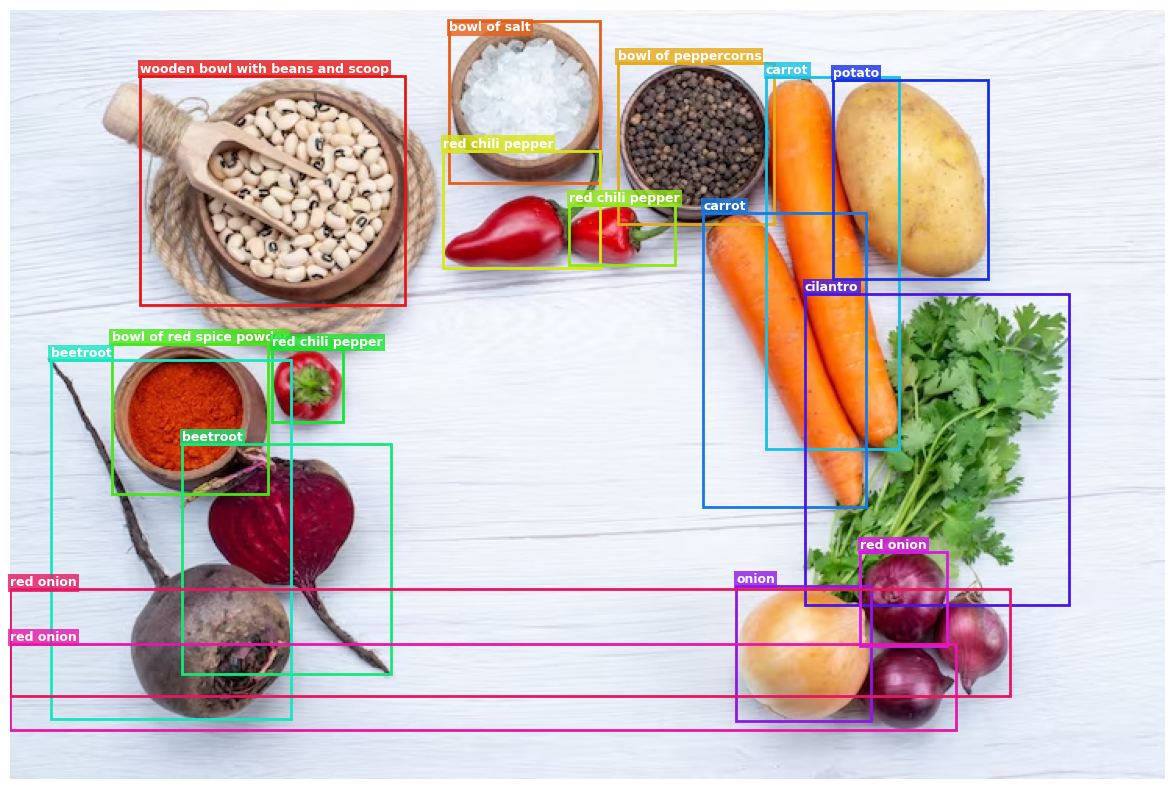

결과 이미지 저장 완료: data/sample_images/detected_objects.jpg


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import colorsys

def draw_bounding_boxes(image_path, detection_result, output_path="result.jpg"):
    """감지된 객체에 바운딩 박스와 라벨을 그려서 저장"""
    
    # 이미지 열기
    image = Image.open(image_path)
    img_w, img_h = image.size
    
    # 그림 생성
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image)
    
    objects = detection_result['objects']
    n = len(objects)
    
    # 객체별 고유 색상 생성
    colors = []
    for i in range(n):
        hue = i / max(n, 1)
        r, g, b = colorsys.hsv_to_rgb(hue, 0.9, 0.9)
        colors.append((r, g, b))
    
    fontsize = max(7, min(12, 14 - n // 3))
    
    for idx, obj in enumerate(objects):
        box = obj['box']
        label = obj['label']
        color = colors[idx]
        
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        # 바운딩 박스 그리기
        rect = patches.Rectangle(
            (x1, y1), width, height,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        
        # 라벨을 박스 왼쪽 상단에 바로 붙이기
        # 박스 위에 공간이 있으면 위에, 없으면 박스 안쪽 상단에 배치
        if y1 > 15:
            ax.text(x1, y1, label, fontsize=fontsize, fontweight='bold',
                    color='white', verticalalignment='bottom',
                    bbox=dict(facecolor=color, alpha=0.8, pad=1.5, edgecolor='none'))
        else:
            ax.text(x1, y1, label, fontsize=fontsize, fontweight='bold',
                    color='white', verticalalignment='top',
                    bbox=dict(facecolor=color, alpha=0.8, pad=1.5, edgecolor='none'))
    
    ax.set_xlim(0, img_w)
    ax.set_ylim(img_h, 0)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f"결과 이미지 저장 완료: {output_path}")

# 실행
draw_bounding_boxes(image_path, detection_result, "data/sample_images/detected_objects.jpg")